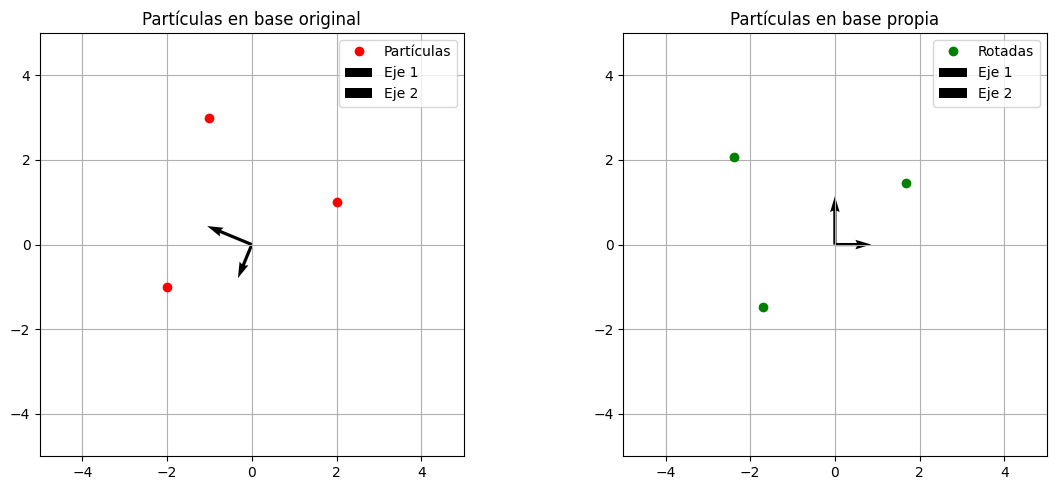

Centro de masa: [-0.33333333  1.          0.        ]
[[ 2  1  0]
 [-1  3  0]
 [-2 -1  0]]
Tensor de inercia:
 [[11. -1.  0.]
 [-1.  9.  0.]
 [ 0.  0. 20.]]
Autovalores (momentos principales): [ 8.58578644 11.41421356 20.        ]
Autovectores (ejes principales):
 [[-0.38268343 -0.92387953  0.        ]
 [-0.92387953  0.38268343  0.        ]
 [-0.          0.          1.        ]]
ω: [2 0 1]
ω en base propia: [-0.76536686 -1.84775907  1.        ]
Tensor de inercia:
 [[ 8.59 -0.    0.  ]
 [ 0.   11.41  0.  ]
 [ 0.    0.   20.  ]]
Momento angular original: [22. -2. 20.]
Momento angular base propia: [ -6.57127645 -21.09071658  20.        ]
Energía cinética original: 32.0
Energía cinética base propia: 32.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# === 1. Coordenadas y masas de las partículas en 2D (z = 0) ===
coords_2D = np.array([
    [2, 1, 0],
    [-1, 3, 0],
    [-2, -1, 0]
])
masses = np.array([1., 1., 1.])

# === 2. Centro de masa ===
total_mass = np.sum(masses)
R_cm = np.average(coords_2D, axis=0, weights=masses)
coords_rel = coords_2D #- R_cm



# === 3. Tensor de inercia respecto al CM ===
I_2D = np.zeros((3, 3))
for r, m in zip(coords_rel, masses):
    r2 = np.dot(r, r)
    I_2D += m * (r2 * np.identity(3) - np.outer(r, r))

# === 4. Diagonalización ===
eigvals, eigvecs = np.linalg.eigh(I_2D)

# === 5. Velocidad angular ===
omega = np.array([2, 0, 1])  # arbitraria, en 3D aunque el sistema es plano

# === 6. Transformaciones ===
omega_prime = eigvecs.T @ omega
L_original = I_2D @ omega
L_prime = np.diag(eigvals) @ omega_prime
T_original = 0.5 * omega @ I_2D @ omega
T_prime = 0.5 * np.dot(eigvals * omega_prime, omega_prime)
I_diag = eigvecs.T @ I_2D @ eigvecs


# === 7. Rotar las partículas a la base propia ===
coords_rotated = coords_rel @ eigvecs

# === 8. Visualización ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set_title("Partículas en base original")
ax1.set_aspect('equal')
ax1.grid(True)
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)
ax1.plot(coords_rel[:, 0], coords_rel[:, 1], 'ro', label='Partículas')

for i in range(2):  # solo eje x-y
    vec = eigvecs[:2, i] * eigvals[i] / 10
    ax1.quiver(0, 0, *vec, angles='xy', scale_units='xy', scale=1, label=f'Eje {i+1}')

ax1.legend()

ax2.set_title("Partículas en base propia")
ax2.set_aspect('equal')
ax2.grid(True)
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)
ax2.plot(coords_rotated[:, 0], coords_rotated[:, 1], 'go', label='Rotadas')

for i in range(2):
    vec = np.zeros(2)
    vec[i] = eigvals[i] / 10
    ax2.quiver(0, 0, *vec, angles='xy', scale_units='xy', scale=1, label=f'Eje {i+1}')

ax2.legend()
plt.tight_layout()
plt.show()

# === 9. Mostrar resultados ===
print("Centro de masa:", R_cm)
print(coords_rel)
print("Tensor de inercia:\n", I_2D)
print("Autovalores (momentos principales):", eigvals)
print("Autovectores (ejes principales):\n", eigvecs)
print("ω:", omega)
print("ω en base propia:", omega_prime)
print("Tensor de inercia:\n", np.round(I_diag,2))
print("Momento angular original:", L_original)
print("Momento angular base propia:", L_prime)
print("Energía cinética original:", T_original)
print("Energía cinética base propia:", T_prime)

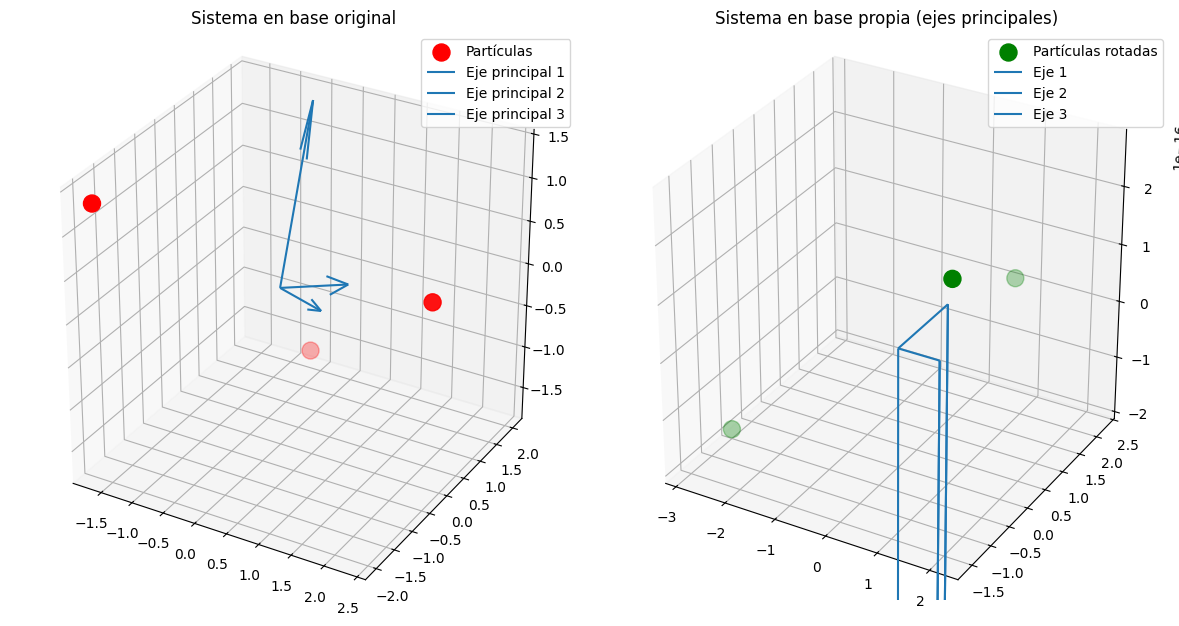

Centro de masa: [-0.33333333  1.          0.66666667]
[[ 2.33333333  0.          0.33333333]
 [-0.66666667  2.         -1.66666667]
 [-1.66666667 -2.          1.33333333]]
Tensor de inercia (respecto al CM):
 [[12.66666667 -2.          0.33333333]
 [-2.         13.33333333  6.        ]
 [ 0.33333333  6.         16.66666667]]
Autovalores (momentos principales): [ 8.06325011 13.27008323 21.33333333]
Autovectores (ejes principales):
 [[ 0.36767708  0.92322939 -0.11162911]
 [ 0.756035   -0.22685685  0.61396013]
 [-0.54150221  0.31013458  0.7814038 ]]
ω: [2 0 1]
ω en base propia: [0.19385195 2.15659337 0.55814557]
Tensor de inercia:
 [[ 8.06 -0.   -0.  ]
 [-0.   13.27  0.  ]
 [-0.   -0.   21.33]]
Momento angular (original): [25.66666667  2.         17.33333333]
Momento angular (base propia): [ 1.56307673 28.61817344 11.90710554]
Energía cinética (original): 34.33333333333333
Energía cinética (base propia): 34.33333333333332


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === 1. Coordenadas y masas de las partículas en 3D ===
coords_3D = np.array([
    [2, 1, 1],
    [-1, 3, -1],
    [-2, -1, 2]
])
masses = np.array([1.0, 1.0, 1.0])

# === 2. Centro de masa ===
total_mass = np.sum(masses)
R_cm = np.average(coords_3D, axis=0, weights=masses)
coords_rel = coords_3D #- R_cm

# === 3. Tensor de inercia respecto al centro de masa ===
I_3D = np.zeros((3, 3))
for r, m in zip(coords_rel, masses):
    r2 = np.dot(r, r)
    I_3D += m * (r2 * np.identity(3) - np.outer(r, r))

# === 4. Diagonalización ===
eigvals, eigvecs = np.linalg.eigh(I_3D)

# === 5. Velocidad angular arbitraria ===
omega = np.array([2, 0, 1])

# === 6. Transformaciones ===
omega_prime = eigvecs.T @ omega
L_original = I_3D @ omega
L_prime = np.diag(eigvals) @ omega_prime
T_original = 0.5 * omega @ I_3D @ omega
T_prime = 0.5 * np.dot(eigvals * omega_prime, omega_prime)
I_diag = eigvecs.T @ I_3D @ eigvecs

# === 7. Rotar coordenadas a la base propia ===
coords_rotated = coords_rel @ eigvecs

# === 8. Visualización ===
fig = plt.figure(figsize=(12, 6))

# --- Base original ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("Sistema en base original")
ax1.scatter(coords_rel[:, 0], coords_rel[:, 1], coords_rel[:, 2], c='r', label='Partículas', s=150)
for i in range(3):
    vec = eigvecs[:, i] * eigvals[i] / 10
    ax1.quiver(0, 0, 0, *vec, label=f'Eje principal {i+1}')
ax1.set_box_aspect([1, 1, 1])
ax1.legend()

# --- Base propia ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("Sistema en base propia (ejes principales)")
ax2.scatter(coords_rotated[:, 0], coords_rotated[:, 1], coords_rotated[:, 2], c='g', label='Partículas rotadas',s=150)
for i in range(3):
    vec = np.zeros(3)
    vec[i] = eigvals[i] / 10
    ax2.quiver(0, 0, 0, *vec, label=f'Eje {i+1}')
ax2.set_box_aspect([1, 1, 1])
ax2.legend()

plt.tight_layout()
plt.show()

# === 9. Mostrar resultados ===
print("Centro de masa:", R_cm)
print(coords_rel)
print("Tensor de inercia (respecto al CM):\n", I_3D)
print("Autovalores (momentos principales):", eigvals)
print("Autovectores (ejes principales):\n", eigvecs)
print("ω:", omega)
print("ω en base propia:", omega_prime)
print("Tensor de inercia:\n", np.round(I_diag,2))
print("Momento angular (original):", L_original)
print("Momento angular (base propia):", L_prime)
print("Energía cinética (original):", T_original)
print("Energía cinética (base propia):", T_prime)